In [58]:
## 0 personalised random seed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

USERNAME = "garima.mittal"
seed = int(hashlib.sha256(USERNAME.encode()).hexdigest(), 16) % (2**32)

print(f"Personalized random seed for user '{USERNAME}' is: {seed}")

Personalized random seed for user 'garima.mittal' is: 3410749789


In [73]:
# Q 1.0 · Dataset Generation
## Generate a synthetic student dataset (10 000 rows) with realistic
## gender/major/program splits and GPA distribution.  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class StudentDataset:
    def __init__(self, num_students: int, seed: int):
        self.num_students = num_students
        self.rng = np.random.default_rng(seed)
        self.data = self._assemble_dataframe()

    def get_full_dataframe(self) -> pd.DataFrame:
        return self.data.copy()

    # ---------- synthetic generators ----------
    def _generate_gender(self):
        return self.rng.choice(['Male','Female','Other'],
                               size=self.num_students,
                               p=[0.65,0.33,0.02])

    def _generate_major(self):
        return self.rng.choice(['B.Tech','MS','PhD'],
                               size=self.num_students,
                               p=[0.70,0.20,0.10])

    def _generate_program(self, majors):
        prog_probs = {
            'B.Tech':[0.40,0.40,0.10,0.10],
            'MS'    :[0.30,0.30,0.20,0.20],
            'PhD'   :[0.25,0.25,0.25,0.25]
        }
        progs=[]
        for m in majors:
            progs.append(self.rng.choice(['CSE','ECE','CHD','CND'],
                                         p=prog_probs[m]))
        return np.array(progs)

    def _generate_gpa(self, majors):
        params={'B.Tech':(7.0,1.0),'MS':(8.0,0.7),'PhD':(8.3,0.5)}
        gpas=[]
        for m in majors:
            mu,sd=params[m]
            gpas.append(np.clip(self.rng.normal(mu,sd),4.0,10.0))
        return np.round(gpas,2)

    def _assemble_dataframe(self):
        majors  = self._generate_major()
        df = pd.DataFrame({
            'gender' : self._generate_gender(),
            'major'  : majors,
            'program': self._generate_program(majors),
            'gpa'    : self._generate_gpa(majors)
        })
        return df

    # ---------- optional plot helper ----------
    def add_plot_metadata(self, title, username=""):
        plt.title(title)
        if USERNAME:
            plt.text(0.95,0.95,USERNAME,ha='right',va='top',
                     transform=plt.gca().transAxes,
                     fontsize=9,color='gray',alpha=.7)

num_students  = 10_000
student_data  = StudentDataset(num_students, seed)
df            = student_data.get_full_dataframe()

print(df.head())


   gender   major program   gpa
0    Male      MS     CHD  6.48
1   Other  B.Tech     ECE  7.56
2    Male  B.Tech     ECE  8.52
3  Female  B.Tech     CHD  4.87
4  Female  B.Tech     ECE  7.83


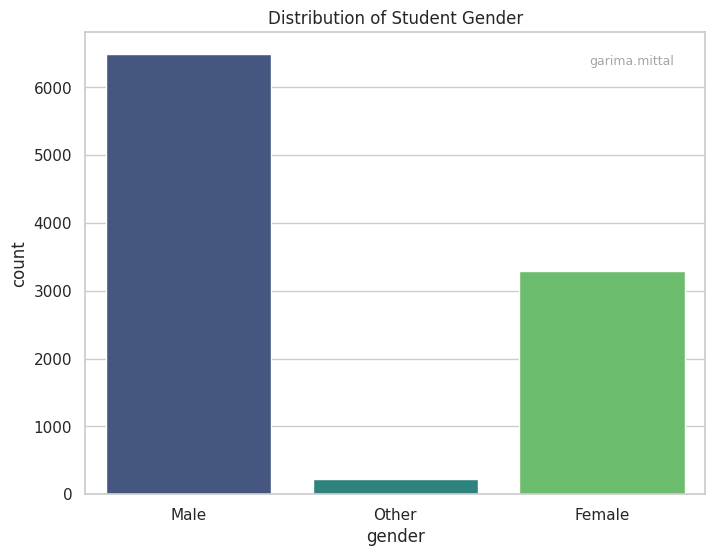

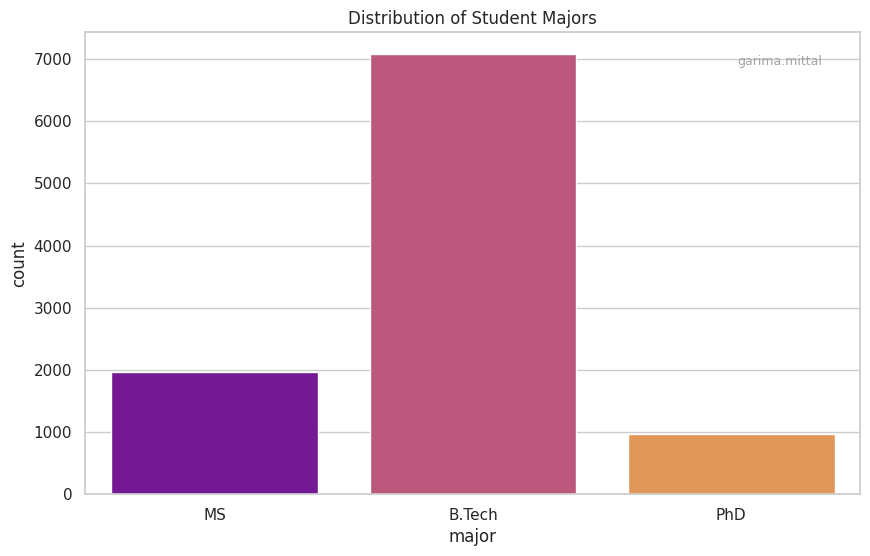

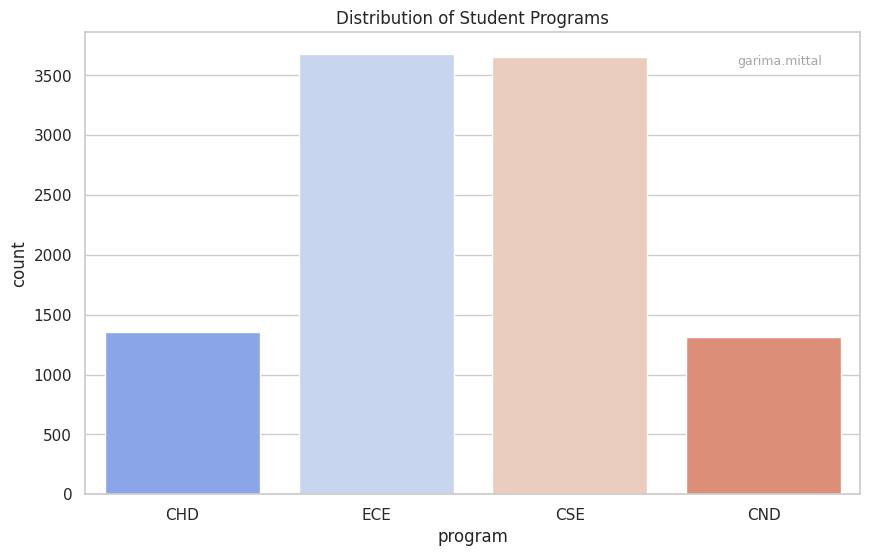

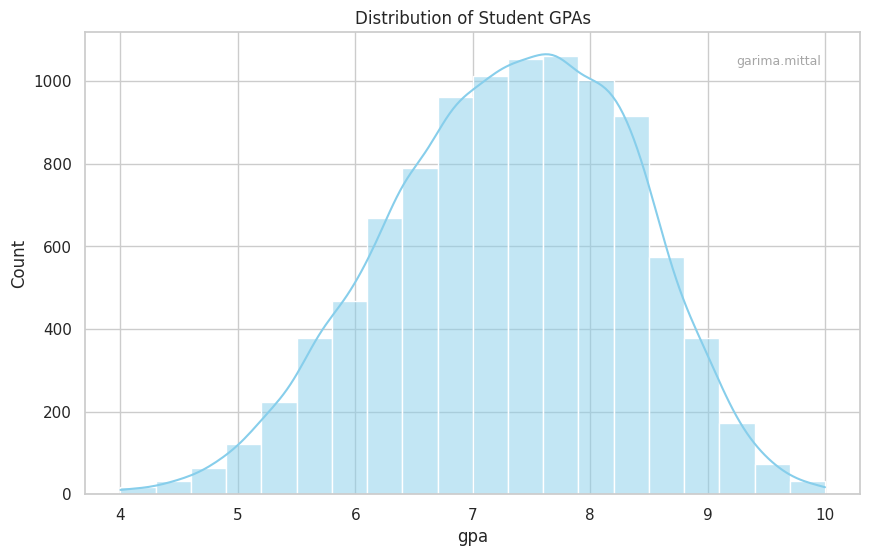

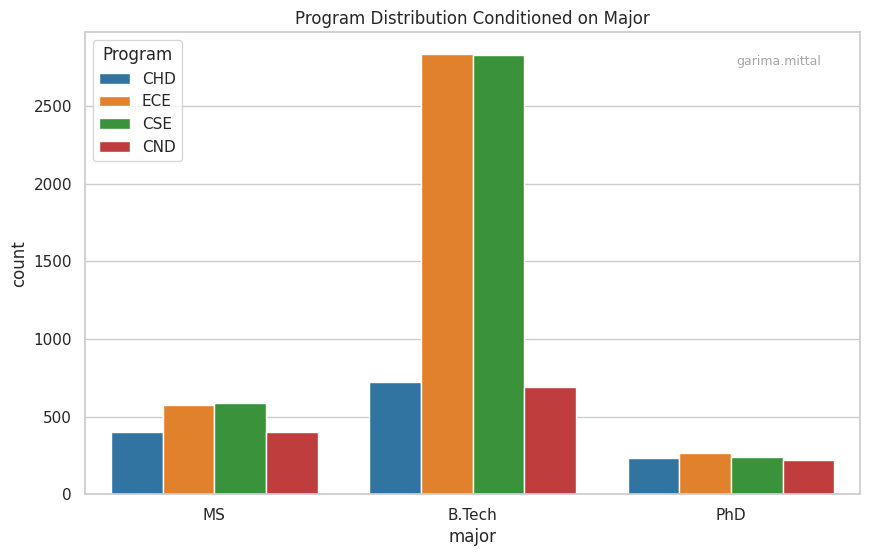

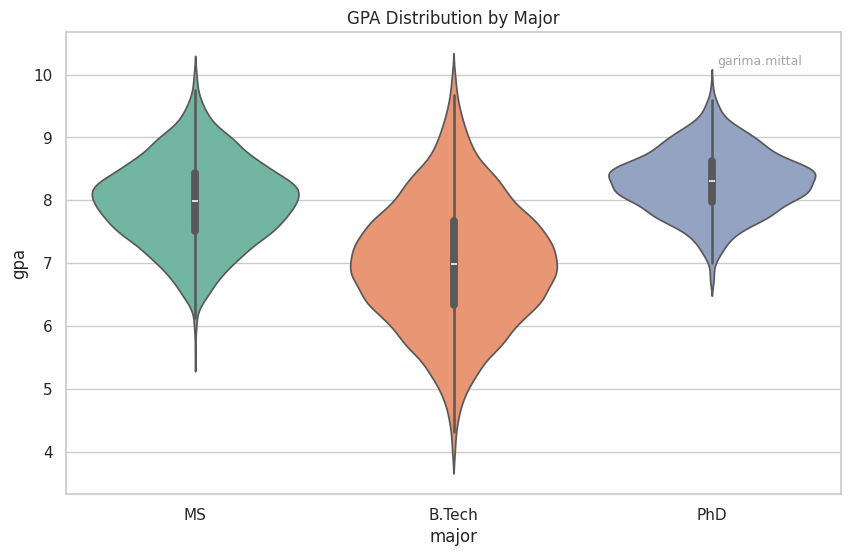

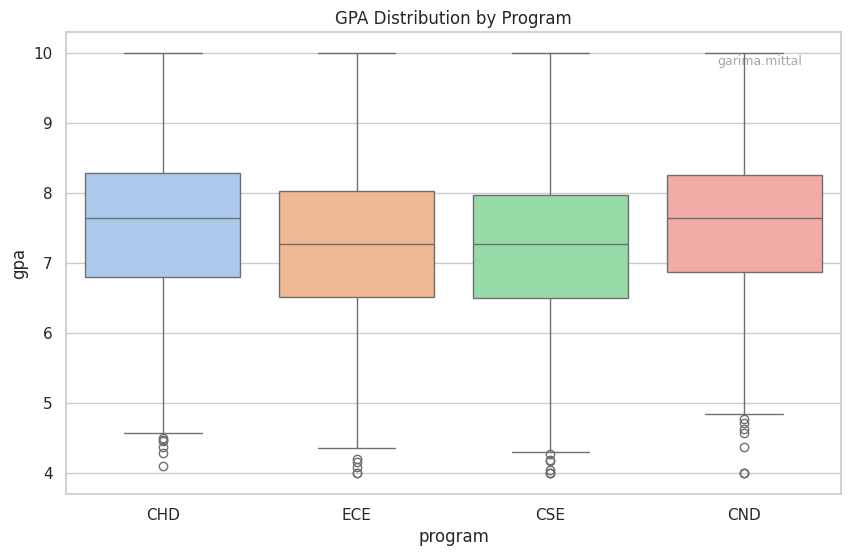

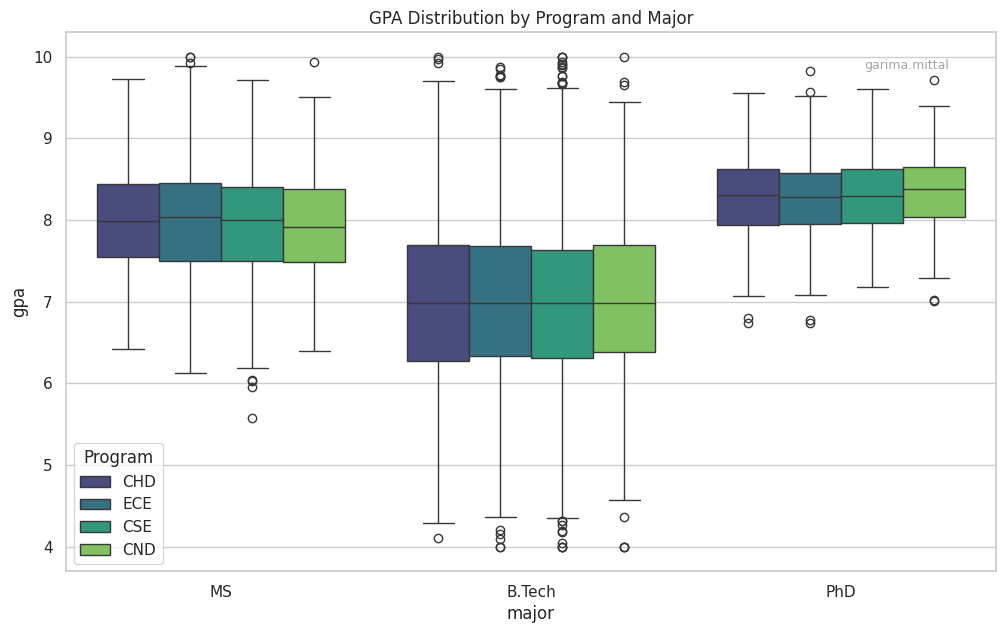

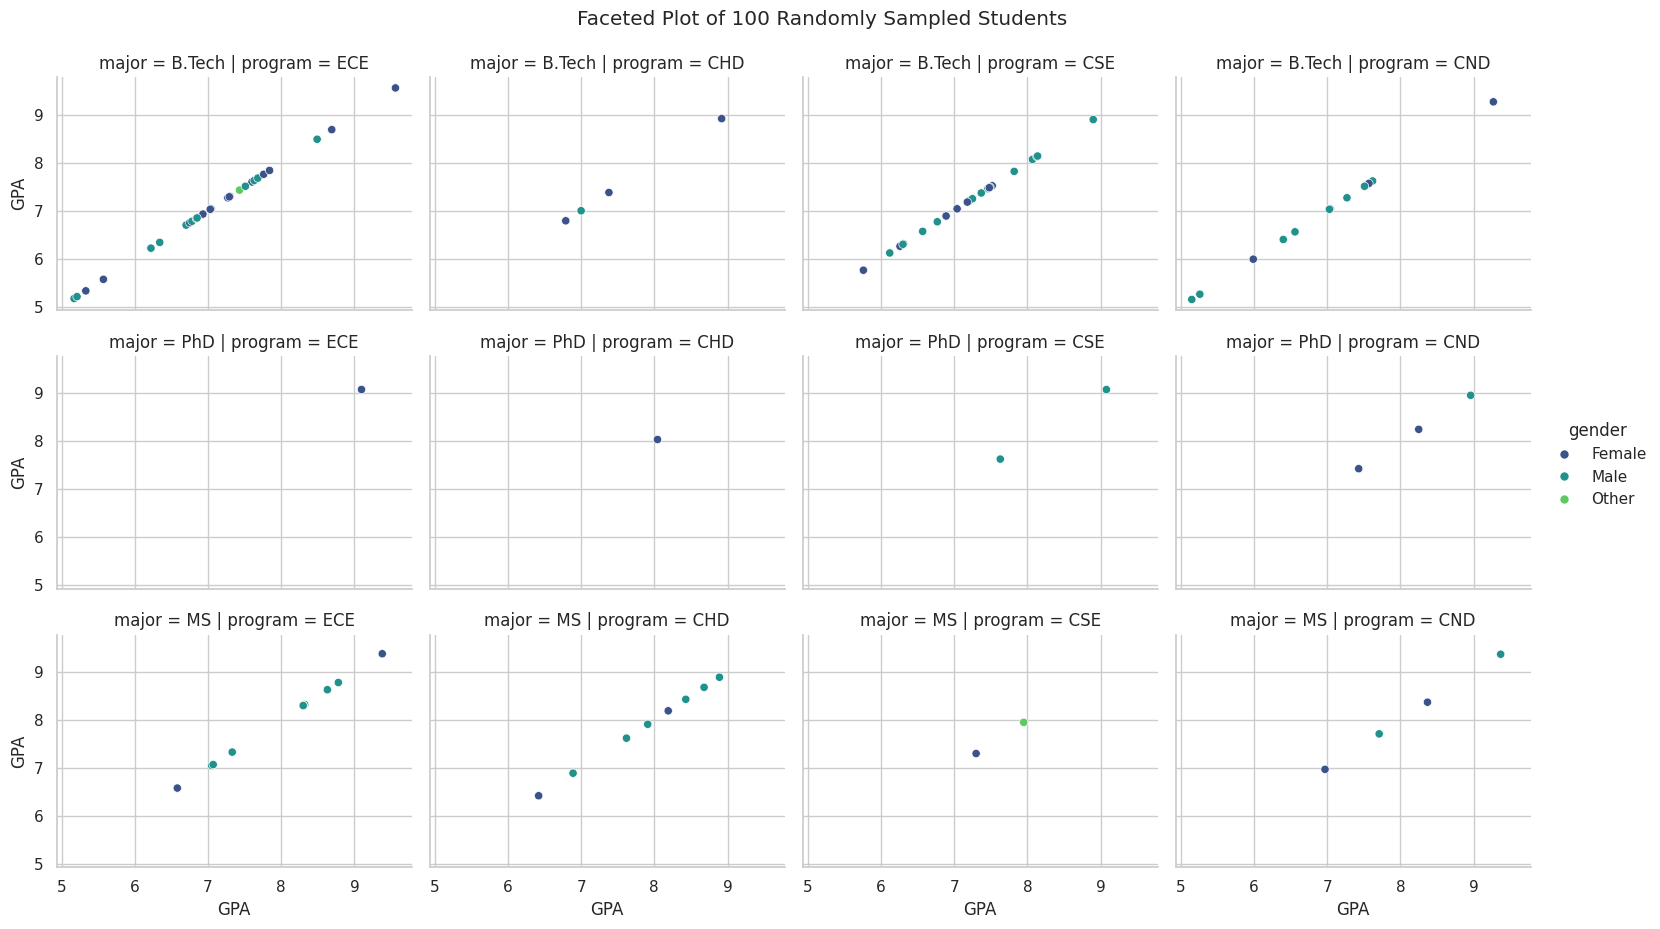

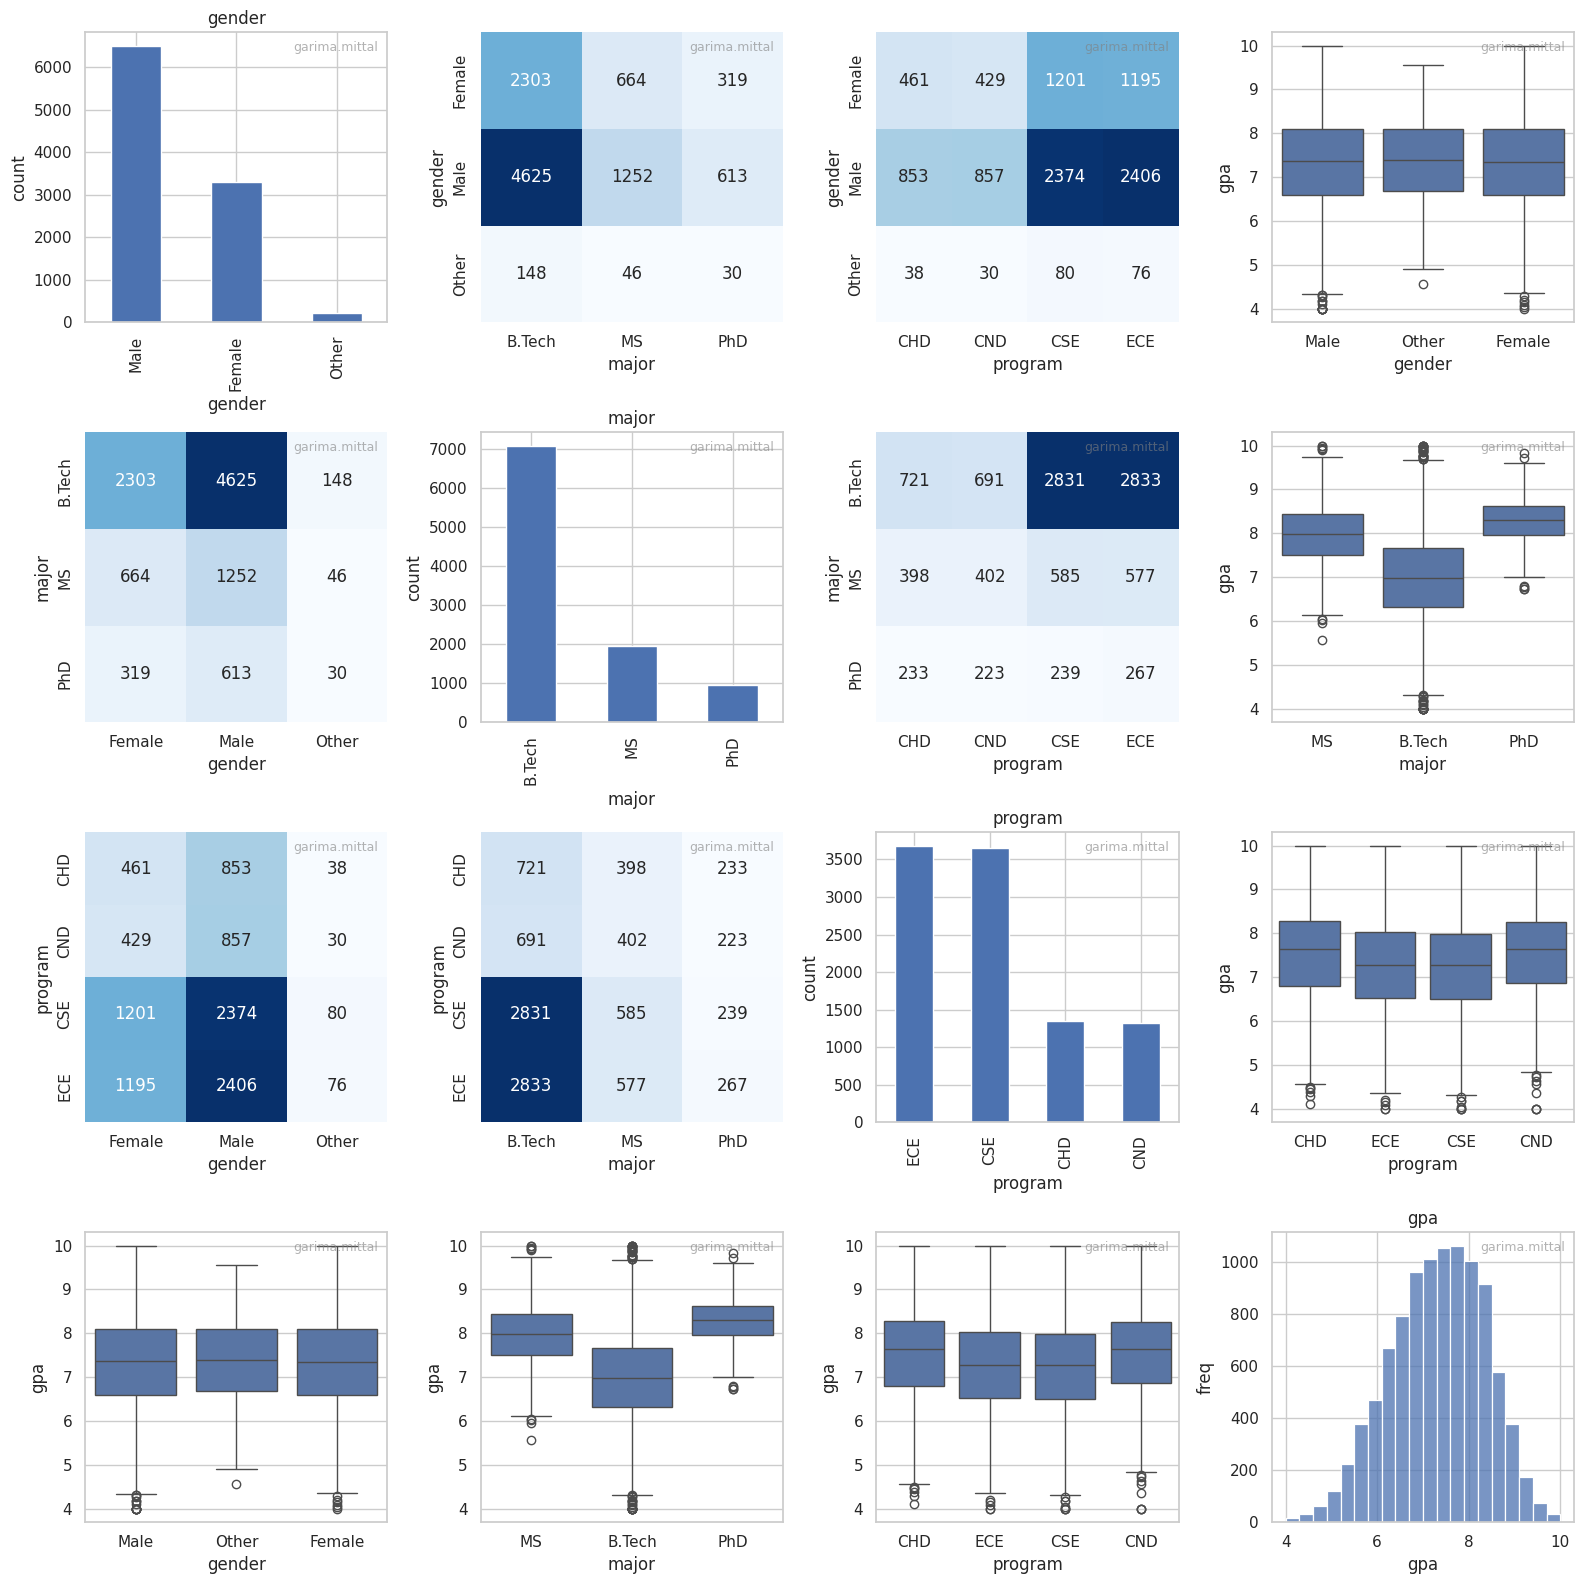

Mean GPA = 7.31,  StdDev = 1.03

Counts per (Major, Program):
 program  CHD  CND   CSE   ECE
major                        
B.Tech   721  691  2831  2833
MS       398  402   585   577
PhD      233  223   239   267 



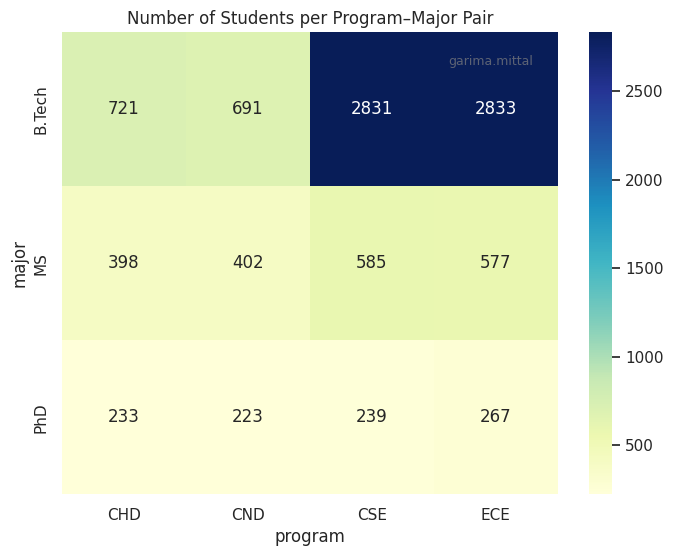

In [74]:
# Q 1.1 · Exploratory Visualisations  
## Reusable helper functions + one-shot figures that summarise the synthetic
## dataset (distributions, conditional plots, pair-grid).

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def make_dataset_pairgrid(df):
    categorical_cols = ['gender', 'major', 'program']
    numeric_cols     = ['gpa']
    all_cols         = categorical_cols + numeric_cols

    def watermark(ax):
        if USERNAME:
            ax.text(0.97, 0.97, USERNAME, ha='right', va='top',
                    transform=ax.transAxes, fontsize=9, color='gray', alpha=0.6)

    n = len(all_cols)
    fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

    for i, row in enumerate(all_cols):
        for j, col in enumerate(all_cols):
            ax = axes[i, j]
            if i == j:
                if row in categorical_cols:
                    df[row].value_counts().plot.bar(ax=ax)
                    ax.set_ylabel("count")
                else:
                    sns.histplot(df[row], bins=20, ax=ax, kde=False)
                    ax.set_ylabel("freq")
                ax.set_title(row)
                watermark(ax)
                continue
            if   (row in categorical_cols and col in numeric_cols):
                sns.boxplot(data=df, x=row, y=col, ax=ax)
            elif (col in categorical_cols and row in numeric_cols):
                sns.boxplot(data=df, x=col, y=row, ax=ax)
            else:          # categorical × categorical
                tbl = pd.crosstab(df[row], df[col])
                sns.heatmap(tbl, annot=True, fmt='d',
                            cmap='Blues', cbar=False, ax=ax)
            watermark(ax)

    plt.tight_layout()
    plt.show()

def plot_gender_distribution(self):
    plt.figure(figsize=(8, 6))
    sns.countplot(x='gender', data=self.data, palette='viridis')
    self.add_plot_metadata('Distribution of Student Gender')
    plt.show()

def plot_major_distribution(self):
    plt.figure(figsize=(10, 6))
    sns.countplot(x='major', data=self.data, palette='plasma')
    self.add_plot_metadata('Distribution of Student Majors')
    plt.show()

def plot_program_distribution(self):
    plt.figure(figsize=(10, 6))
    sns.countplot(x='program', data=self.data, palette='coolwarm')
    self.add_plot_metadata('Distribution of Student Programs')
    plt.show()

def plot_gpa_distribution(self, bins: int = 20):
    plt.figure(figsize=(10, 6))
    sns.histplot(x='gpa', data=self.data, bins=bins, kde=True, color='skyblue')
    self.add_plot_metadata('Distribution of Student GPAs')
    plt.show()

def plot_program_by_major(self):
    plt.figure(figsize=(10, 6))
    sns.countplot(x='major', hue='program', data=self.data, palette='tab10')
    self.add_plot_metadata('Program Distribution Conditioned on Major')
    plt.legend(title='Program')
    plt.show()

def plot_gpa_by_major(self):
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='major', y='gpa', data=self.data, palette='Set2')
    self.add_plot_metadata('GPA Distribution by Major')
    plt.show()

def plot_gpa_by_program(self):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='program', y='gpa', data=self.data, palette='pastel')
    self.add_plot_metadata('GPA Distribution by Program')
    plt.show()

def plot_gpa_by_program_and_major(self):
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='major', y='gpa', hue='program', data=self.data, palette='viridis')
    self.add_plot_metadata('GPA Distribution by Program and Major')
    plt.legend(title='Program')
    plt.show()

def plot_sampled_dataset(self, n: int = 100):
    sampled_df = self.data.sample(n=n, random_state=self.rng.integers(1e9))
    g = sns.relplot(
        data=sampled_df,
        x='gpa', y='gpa',
        col='program', row='major',
        hue='gender', kind='scatter',
        palette='viridis',
        height=3, aspect=1.3
    )
    g.fig.suptitle(f'Faceted Plot of {n} Randomly Sampled Students', y=1.03)
    g.set_axis_labels("GPA", "GPA")
    plt.show()

def plot_entire_dataset_summary(self):
    make_dataset_pairgrid(self.data)

def gpa_mean_std(self):
    return self.data['gpa'].mean(), self.data['gpa'].std()

def count_students_per_program_major_pair(self):
    return pd.crosstab(self.data['major'], self.data['program'])

def visualize_students_per_program_major_pair(self, counts_df):
    plt.figure(figsize=(8, 6))
    sns.heatmap(counts_df, annot=True, fmt='d', cmap='YlGnBu')
    self.add_plot_metadata('Number of Students per Program–Major Pair')
    plt.show()

StudentDataset.plot_gender_distribution               = plot_gender_distribution
StudentDataset.plot_major_distribution                = plot_major_distribution
StudentDataset.plot_program_distribution              = plot_program_distribution
StudentDataset.plot_gpa_distribution                  = plot_gpa_distribution
StudentDataset.plot_program_by_major                  = plot_program_by_major
StudentDataset.plot_gpa_by_major                      = plot_gpa_by_major
StudentDataset.plot_gpa_by_program                    = plot_gpa_by_program
StudentDataset.plot_gpa_by_program_and_major          = plot_gpa_by_program_and_major
StudentDataset.plot_sampled_dataset                   = plot_sampled_dataset
StudentDataset.plot_entire_dataset_summary            = plot_entire_dataset_summary
StudentDataset.gpa_mean_std                           = gpa_mean_std
StudentDataset.count_students_per_program_major_pair  = count_students_per_program_major_pair
StudentDataset.visualize_students_per_program_major_pair = visualize_students_per_program_major_pair

student_data = StudentDataset(num_students=10000, seed=seed)
df = student_data.get_full_dataframe()        

student_data.plot_gender_distribution()
student_data.plot_major_distribution()
student_data.plot_program_distribution()
student_data.plot_gpa_distribution()
student_data.plot_program_by_major()
student_data.plot_gpa_by_major()
student_data.plot_gpa_by_program()
student_data.plot_gpa_by_program_and_major()
student_data.plot_sampled_dataset()
student_data.plot_entire_dataset_summary()

mu, sd = student_data.gpa_mean_std()
print(f"Mean GPA = {mu:.2f},  StdDev = {sd:.2f}\n")

counts = student_data.count_students_per_program_major_pair()
print("Counts per (Major, Program):\n", counts, "\n")
student_data.visualize_students_per_program_major_pair(counts)


In [61]:
def get_gpa_mean_std_random(self, n: int = 500, repeats: int = 50) -> tuple[float, float]:
    sample_means = []
    for _ in range(repeats):
        sample = self.data.sample(n=n, random_state=self.rng)
        sample_means.append(sample['gpa'].mean())
    mean_gpas_np = np.array(sample_means)
    return (mean_gpas_np.mean(), mean_gpas_np.std())

def get_gpa_mean_std_stratified(self, n: int = 500, repeats: int = 50) -> tuple[float, float]:
    sample_means = []
    major_proportions = self.data['major'].value_counts(normalize=True)
    for _ in range(repeats):
        stratified_sample = pd.DataFrame()
        for major, prop in major_proportions.items():
            num_to_sample = int(n * prop)
            major_sample = self.data[self.data['major'] == major].sample(n=num_to_sample, random_state=self.rng)
            stratified_sample = pd.concat([stratified_sample, major_sample])
        sample_means.append(stratified_sample['gpa'].mean())
    mean_gpas_np = np.array(sample_means)
    return (mean_gpas_np.mean(), mean_gpas_np.std())

StudentDataset.get_gpa_mean_std_random = get_gpa_mean_std_random
StudentDataset.get_gpa_mean_std_stratified = get_gpa_mean_std_stratified

random_avg_mean, random_std_of_means = student_data.get_gpa_mean_std_random()
print("--- Simple Random Sampling Results (50 Repetitions) ---")
print(f"Average of 50 sample mean GPAs: {random_avg_mean:.4f}")
print(f"Standard deviation of the 50 mean GPAs: {random_std_of_means:.4f}")

stratified_avg_mean, stratified_std_of_means = student_data.get_gpa_mean_std_stratified()
print("\n--- Stratified Sampling Results (50 Repetitions) ---")
print(f"Average of 50 sample mean GPAs: {stratified_avg_mean:.4f}")
print(f"Standard deviation of the 50 mean GPAs: {stratified_std_of_means:.4f}")

print("\nWhich method has lower std deviation? Why?")
print(f"The standard deviation of the mean GPAs from stratified sampling ({stratified_std_of_means:.4f}) is lower than that from simple random sampling ({random_std_of_means:.4f}). This is because stratified sampling reduces sampling variability by ensuring each sample's major composition accurately reflects the population's. This leads to the sample means being more tightly clustered around the true population mean, resulting in a lower standard deviation of the means.")

--- Simple Random Sampling Results (50 Repetitions) ---
Average of 50 sample mean GPAs: 7.3155
Standard deviation of the 50 mean GPAs: 0.0471

--- Stratified Sampling Results (50 Repetitions) ---
Average of 50 sample mean GPAs: 7.3118
Standard deviation of the 50 mean GPAs: 0.0390

Which method has lower std deviation? Why?
The standard deviation of the mean GPAs from stratified sampling (0.0390) is lower than that from simple random sampling (0.0471). This is because stratified sampling reduces sampling variability by ensuring each sample's major composition accurately reflects the population's. This leads to the sample means being more tightly clustered around the true population mean, resulting in a lower standard deviation of the means.


--- Exact Gender-Balanced Cohort (5 Repeats) ---
Repeat 1: {'Female': 100, 'Male': 100, 'Other': 100}
Repeat 2: {'Female': 100, 'Male': 100, 'Other': 100}
Repeat 3: {'Female': 100, 'Male': 100, 'Other': 100}
Repeat 4: {'Female': 100, 'Male': 100, 'Other': 100}
Repeat 5: {'Female': 100, 'Male': 100, 'Other': 100}

--- Sampling Strategy A Cohort (5 Repeats) ---
Repeat 1: {'Female': 106, 'Other': 99, 'Male': 95}
Repeat 2: {'Female': 111, 'Other': 105, 'Male': 84}
Repeat 3: {'Female': 107, 'Male': 101, 'Other': 92}
Repeat 4: {'Male': 105, 'Female': 100, 'Other': 95}
Repeat 5: {'Other': 107, 'Female': 101, 'Male': 92}


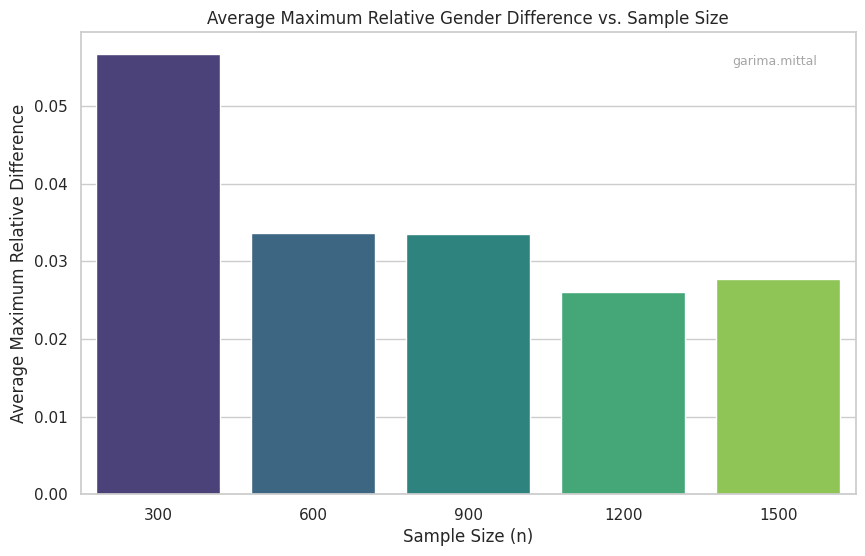

In [75]:
# Add sampling methods for gender
def get_gender_balanced_counts(self, n: int = 300, repeats: int = 5) -> list[dict[str, int]]:
    if n % len(self.data['gender'].unique()) != 0:
        raise ValueError("n must be a multiple of the number of genders.")
    count_per_gender = n // len(self.data['gender'].unique())
    all_sample_counts = []
    for _ in range(repeats):
        balanced_sample = self.data.groupby('gender').sample(n=count_per_gender, random_state=self.rng)
        counts = balanced_sample['gender'].value_counts().to_dict()
        all_sample_counts.append(counts)
    return all_sample_counts

def sample_gender_uniform_random(self, n: int = 300, repeats: int = 5) -> list[dict[str, int]]:
    genders = self.data['gender'].unique()
    gender_dfs = {gender: self.data[self.data['gender'] == gender] for gender in genders}
    all_sample_counts = []
    for _ in range(repeats):
        sample_list = []
        for _ in range(n):
            selected_gender = self.rng.choice(genders)
            student = gender_dfs[selected_gender].sample(n=1, random_state=self.rng)
            sample_list.append(student)
        sample_df = pd.concat(sample_list, ignore_index=True)
        counts = sample_df['gender'].value_counts().to_dict()
        all_sample_counts.append(counts)
    return all_sample_counts

def plot_avg_max_gender_diff_vs_sample_size(self, sample_sizes: list[int], repeats: int = 10) -> None:
    genders = self.data['gender'].unique()
    gender_dfs = {gender: self.data[self.data['gender'] == gender] for gender in genders}
    avg_max_relative_diffs = []
    for n in sample_sizes:
        max_relative_diffs_for_n = []
        for _ in range(repeats):
            sample_list = []
            for _ in range(n):
                selected_gender = self.rng.choice(genders)
                student = gender_dfs[selected_gender].sample(n=1, random_state=self.rng)
                sample_list.append(student)
            sample_df = pd.concat(sample_list, ignore_index=True)
            counts = sample_df['gender'].value_counts().to_dict()
            for gender in genders:
                if gender not in counts:
                    counts[gender] = 0
            max_count = max(counts.values())
            min_count = min(counts.values())
            max_diff = max_count - min_count
            max_relative_diff = max_diff / n
            max_relative_diffs_for_n.append(max_relative_diff)
        avg_max_relative_diffs.append(np.mean(max_relative_diffs_for_n))
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sample_sizes, y=avg_max_relative_diffs, palette='viridis')
    plt.title('Average Maximum Relative Gender Difference vs. Sample Size')
    plt.xlabel('Sample Size (n)')
    plt.ylabel('Average Maximum Relative Difference')
    plt.text(0.95,0.95,USERNAME,ha='right',va='top',
                     transform=plt.gca().transAxes,
                     fontsize=9,color='gray',alpha=.7)
    plt.show()

StudentDataset.get_gender_balanced_counts = get_gender_balanced_counts
StudentDataset.sample_gender_uniform_random = sample_gender_uniform_random
StudentDataset.plot_avg_max_gender_diff_vs_sample_size = plot_avg_max_gender_diff_vs_sample_size

# --- Part 1: Exact Gender Balance --- [cite: 136]
balanced_counts = student_data.get_gender_balanced_counts()
print("--- Exact Gender-Balanced Cohort (5 Repeats) ---")
for i, counts in enumerate(balanced_counts):
    print(f"Repeat {i+1}: {counts}")

# --- Part 2: Sampling Strategy A --- [cite: 138, 139]
uniform_random_counts = student_data.sample_gender_uniform_random()
print("\n--- Sampling Strategy A Cohort (5 Repeats) ---")
for i, counts in enumerate(uniform_random_counts):
    print(f"Repeat {i+1}: {counts}")

# --- Part 3: Difference vs Sample Size --- [cite: 142-145]
sample_sizes = [300, 600, 900, 1200, 1500]
student_data.plot_avg_max_gender_diff_vs_sample_size(sample_sizes=sample_sizes)

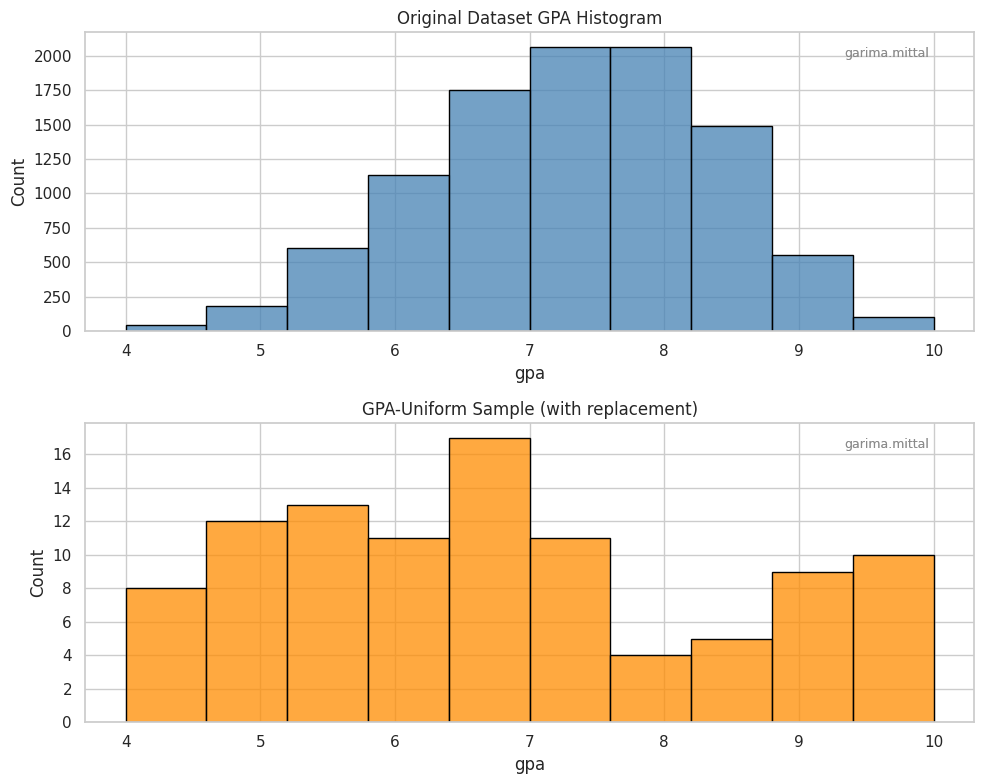

Unique students in sample: 100 (may be < 100 because sampling is WITH replacement)


4.00 – 4.60      8
4.60 – 5.20     12
5.20 – 5.80     13
5.80 – 6.40     11
6.40 – 7.00     17
7.00 – 7.60     11
7.60 – 8.20      4
8.20 – 8.80      5
8.80 – 9.40      9
9.40 – 10.00    10
Name: count, dtype: int64

In [76]:
student_data = StudentDataset(num_students=10_000, seed=seed)
df = student_data.get_full_dataframe()

# ──────────────────────────────────────────────────────────────────────────────
# Q1.4  –– GPA-Uniform Cohort  (WITH REPLACEMENT)
# ──────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def sample_gpa_uniform_wr(self, n: int = 100, bins: int = 10) -> pd.DataFrame:
    """
    Sampling Strategy A with **replacement**:
      1. Partition GPA into `bins` equal-width intervals.
      2. For each of n draws:
           • pick a bin uniformly at random
           • pick a student uniformly at random from *that* bin
           • (no removal → same student can be chosen again)
      3. Return the sampled DataFrame – may contain duplicates.
    """
    # Assign every student to a bin
    _, edges = np.histogram(self.data['gpa'], bins=bins)
    bin_labels = pd.cut(self.data['gpa'], bins=edges, include_lowest=True)

    # Map bins → indices
    bin_to_indices = {b: self.data.index[bin_labels == b].to_numpy()
                      for b in bin_labels.cat.categories}

    rng = self.rng
    sampled_idx = []

    for _ in range(n):
        chosen_bin = rng.choice(bin_labels.cat.categories)          # uniform over bins
        chosen_idx = rng.choice(bin_to_indices[chosen_bin])         # uniform within bin
        sampled_idx.append(chosen_idx)

    return self.data.loc[sampled_idx].reset_index(drop=True)

def plot_gpa_histogram_comparison_wr(self, sampled_df: pd.DataFrame, bins: int = 10):
    """
    Stacked bar/histograms comparing GPA distribution of:
      • full dataset   • GPA-uniform sample (with replacement)
    """
    plt.figure(figsize=(10, 8))

    # Original dataset
    plt.subplot(2, 1, 1)
    sns.histplot(self.data['gpa'], bins=bins,
                 color='steelblue', edgecolor='black')
    plt.text(0.95,0.95,USERNAME,ha='right',va='top',
                     transform=plt.gca().transAxes,
                     fontsize=9,color='gray',alpha=.7)
    self.add_plot_metadata('Original Dataset GPA Histogram')

    # Sampled dataset
    plt.subplot(2, 1, 2)
    sns.histplot(sampled_df['gpa'], bins=bins,
                 color='darkorange', edgecolor='black')
    self.add_plot_metadata('GPA-Uniform Sample (with replacement)')

    plt.tight_layout()
    plt.text(0.95,0.95,USERNAME,ha='right',va='top',
                     transform=plt.gca().transAxes,
                     fontsize=9,color='gray',alpha=.7)
    plt.show()

# Attach to class
StudentDataset.sample_gpa_uniform_wr            = sample_gpa_uniform_wr
StudentDataset.plot_gpa_histogram_comparison_wr = plot_gpa_histogram_comparison_wr

# ──────────────────────────────────────────────────────────────────────────────
# Example run  (uncomment to test)
# ──────────────────────────────────────────────────────────────────────────────
sample_wr = student_data.sample_gpa_uniform_wr(n=100, bins=10)
student_data.plot_gpa_histogram_comparison_wr(sample_wr)

print(f"Unique students in sample: {sample_wr.index.nunique()} "
      f"(may be < 100 because sampling is WITH replacement)")

# ──────────────────────────────────────────────────────────────────────────────
# Print GPA-bin counts (works for any DataFrame with a 'gpa' column)
# ──────────────────────────────────────────────────────────────────────────────
# Option A – no internal print, rely on auto-display
def gpa_bin_counts(self, df: pd.DataFrame, bins=10):
    counts, edges = np.histogram(df['gpa'], bins=bins)
    labels = [f"{edges[i]:.2f} – {edges[i+1]:.2f}" for i in range(bins)]
    return pd.Series(counts, index=labels, name='count')

StudentDataset.gpa_bin_counts = gpa_bin_counts

student_data.gpa_bin_counts(sample_wr, bins=10)     # shows once






major    B.Tech  MS  PhD
program                 
CHD           4   1    4
CND           5   5    5
CSE           5   5    3
ECE          11   6    6 



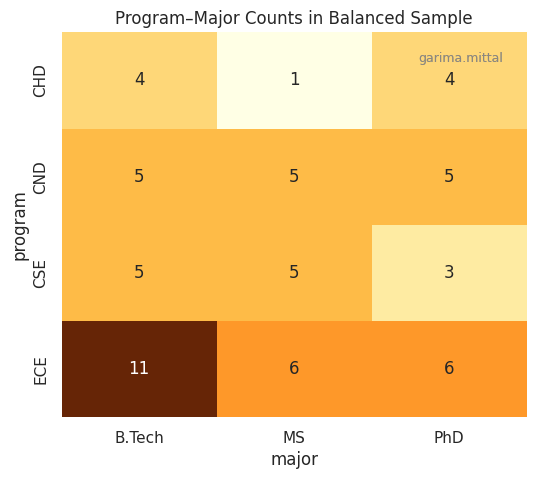

Sampling is WITH replacement.  If a (program, major) category has few real students, the same student may appear multiple times to keep category counts roughly equal.
Note on too-small categories:
If a (program, major) pair contains fewer distinct students than the ≈5 draws allotted to it, the code keeps sampling WITH replacement from the tiny pool.  As a result the same student ID may appear more than once, but category counts stay close to n / 12, keeping the cohort approximately balanced across all program-major combinations.


In [77]:
# ──────────────────────────────────────────────────────────────────────────────
# Q1.5 – Program-Major Balanced Cohort  (WITH replacement)
# ──────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def sample_program_major_balanced(self, n: int = 60) -> pd.DataFrame:
    """
    Strategy A with **replacement** to obtain ≈ balanced counts across the
    |program| × |major| combinations.
    """
    programs = self.data['program'].unique()
    majors   = self.data['major'].unique()
    categories = [(p, m) for p in programs for m in majors]        # 12 pairs

    # map each pair → array of student indices in that category
    cat_to_idx = {cat: self.data.index[
                    (self.data['program'] == cat[0]) &
                    (self.data['major']   == cat[1])
                  ].to_numpy()
                  for cat in categories}

    rng   = self.rng
    picks = []

    while len(picks) < n:
        cat = categories[rng.integers(len(categories))]            # uniform over categories
        pool = cat_to_idx[cat]
        if pool.size == 0:                                         # category empty – skip
            continue
        picks.append(int(rng.choice(pool)))                        # WITH replacement

    return self.data.loc[picks].reset_index(drop=True)


def show_program_major_counts_and_heatmap(self, sampled_df: pd.DataFrame,
                                          annot: bool = True) -> None:
    """Print counts and show a heat-map for the balanced cohort."""
    counts = pd.crosstab(sampled_df['program'], sampled_df['major'])
    print(counts, '\n')

    plt.figure(figsize=(6, 5))
    sns.heatmap(counts, annot=annot, fmt='d', cmap='YlOrBr', cbar=False)
    self.add_plot_metadata('Program–Major Counts in Balanced Sample')
    plt.text(0.95,0.95,USERNAME,ha='right',va='top',
                     transform=plt.gca().transAxes,
                     fontsize=9,color='gray',alpha=.7)
    plt.show()


# Attach new methods to the class
StudentDataset.sample_program_major_balanced         = sample_program_major_balanced
StudentDataset.show_program_major_counts_and_heatmap = show_program_major_counts_and_heatmap


# ──────────────────────────────────────────────────────────────────────────────
# Example usage  (uncomment to test)
# ──────────────────────────────────────────────────────────────────────────────
sample_bal = student_data.sample_program_major_balanced(n=60)
student_data.show_program_major_counts_and_heatmap(sample_bal)

print("Sampling is WITH replacement.  If a (program, major) category has few"
      " real students, the same student may appear multiple times to keep "
      "category counts roughly equal.")

print(
        "Note on too-small categories:\n"
        "If a (program, major) pair contains fewer distinct students than the "
        "≈5 draws allotted to it, the code keeps sampling WITH replacement "
        "from the tiny pool.  As a result the same student ID may appear more "
        "than once, but category counts stay close to n / 12, keeping the "
        "cohort approximately balanced across all program-major combinations."
    )


In [78]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedShuffleSplit

class PerFeatureTransformer:
    """
    Initializes memory for per-feature transformers.
    """
    def __init__(self):
        self.transformers = []
        self.feature_names = []
        self.preprocessor = None

    def fit(self, df: pd.DataFrame, params: dict[str, str]) -> None:
        """
        Fits transformers for each feature based on the given type.
        """
        # A list to hold the (name, transformer, columns) tuples
        transformers_list = []
        
        for feature, transform_type in params.items():
            if transform_type == 'standard':
                transformer = StandardScaler()
            elif transform_type == 'onehot':
                transformer = OneHotEncoder(handle_unknown='ignore')
            elif transform_type == 'ordinal':
                transformer = OrdinalEncoder(handle_unknown='ignore')
            else:
                raise ValueError(f"Unsupported transform type: {transform_type}")
            
            # The list needs a tuple of (name, transformer_object, columns_to_apply)
            transformers_list.append((feature, transformer, [feature]))
        
        self.feature_names = list(params.keys())
        self.preprocessor = ColumnTransformer(
            transformers_list,
            remainder='passthrough',
            n_jobs=-1
        )
        self.preprocessor.fit(df[self.feature_names])

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        """
        Applies the fitted transformers to the corresponding features and returns a NumPy array.
        """
        return self.preprocessor.transform(df[self.feature_names])

    def fit_transform(self, df: pd.DataFrame, params: dict[str, str]) -> np.ndarray:
        """
        Fits and transforms all features in one step using the given transformation parameters.
        """
        self.fit(df, params)
        return self.transform(df)

In [79]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedShuffleSplit

class KNNGenderPredictor:
    """
    Initializes the predictor with the full student dataset.
    """
    def __init__(self, student_df: pd.DataFrame, username: USERNAME):
        self.df = student_df
        self.username = username
        self.X_train, self.X_val, self.X_test = None, None, None
        self.y_train, self.y_val, self.y_test = None, None, None
        self.transformer = PerFeatureTransformer()
        # Add a LabelEncoder for the target variable 'gender'
        self.label_encoder = LabelEncoder()
    
    def train_val_test_split(self, test_size: float = 0.2, val_size: float = 0.2) -> tuple:
        # Encode gender labels to numerical format
        y_encoded = self.label_encoder.fit_transform(self.df['gender'])
        
        # First, split off the test set
        sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        for train_val_index, test_index in sss.split(self.df, self.df['gender']):
            train_val_set = self.df.iloc[train_val_index]
            self.X_test = self.df.iloc[test_index].drop(columns=['gender'])
            self.y_test = pd.Series(y_encoded[test_index], index=self.X_test.index)

        # Next, split the remaining data into train and validation sets
        sss = StratifiedShuffleSplit(n_splits=1, test_size=val_size / (1 - test_size), random_state=seed)
        for train_index, val_index in sss.split(train_val_set, train_val_set['gender']):
            self.X_train = train_val_set.iloc[train_index].drop(columns=['gender'])
            self.y_train = pd.Series(y_encoded[train_index], index=self.X_train.index)
            self.X_val = train_val_set.iloc[val_index].drop(columns=['gender'])
            self.y_val = pd.Series(y_encoded[val_index], index=self.X_val.index)
        
        return self.X_train, self.X_val, self.X_test, self.y_train, self.y_val, self.y_test

    def get_feature_matrix(self, df: pd.DataFrame, features: list[str]) -> np.ndarray:
        if not self.transformer.feature_names:
            params = {feat: 'onehot' if df[feat].dtype == 'object' else 'standard' for feat in features}
            self.transformer.fit(df, params)
        return self.transformer.transform(df)

    def get_knn_accuracy_vs_k(self, k_values: list[int], distance: str = "euclidean") -> list[float]:
        accuracies = []
        features_to_use = ['major', 'program', 'gpa']
        X_train_transformed = self.get_feature_matrix(self.X_train, features_to_use)
        X_val_transformed = self.get_feature_matrix(self.X_val, features_to_use)
        
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric=distance)
            knn.fit(X_train_transformed, self.y_train)
            y_pred = knn.predict(X_val_transformed)
            accuracies.append(accuracy_score(self.y_val, y_pred))
            
        return accuracies

    def plot_knn_accuracy_vs_k(self, k_values: list[int], distance: str = "euclidean") -> None:
        accuracies = self.get_knn_accuracy_vs_k(k_values, distance)
        plt.figure(figsize=(10, 6))
        plt.plot(k_values, accuracies, marker='o')
        plt.title(f'k-NN Accuracy vs. k (Distance: {distance.capitalize()})')
        plt.xlabel('k (Number of Neighbors)')
        plt.ylabel('Accuracy Score')
        plt.xticks(k_values)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.text(0.95, 0.95, self.username, ha='right', va='top', transform=plt.gca().transAxes,
                 fontsize=10, color='gray', alpha=0.7)
        plt.show()
        
    def get_knn_f1_heatmap(self, k_values: list[int], distances: list[str]) -> pd.DataFrame:
        features_to_use = ['major', 'program', 'gpa']
        X_train_transformed = self.get_feature_matrix(self.X_train, features_to_use)
        X_val_transformed = self.get_feature_matrix(self.X_val, features_to_use)

        results = {}
        for distance in distances:
            f1_scores = []
            for k in k_values:
                knn = KNeighborsClassifier(n_neighbors=k, metric=distance)
                knn.fit(X_train_transformed, self.y_train)
                y_pred = knn.predict(X_val_transformed)
                f1 = f1_score(self.y_val, y_pred, average='weighted')
                f1_scores.append(f1)
            results[distance] = f1_scores
            
        return pd.DataFrame(results, index=k_values)

    def plot_knn_f1_heatmap(self, f1_scores_df: pd.DataFrame) -> None:
        plt.figure(figsize=(10, 8))
        sns.heatmap(f1_scores_df, annot=True, fmt=".3f", cmap="viridis")
        plt.title('Validation F-1 Score Heatmap')
        plt.xlabel('Distance Metric')
        plt.ylabel('k (Number of Neighbors)')
        plt.text(0.95, 0.95, self.username, ha='right', va='top', transform=plt.gca().transAxes,
                 fontsize=10, color='gray', alpha=0.7)
        plt.show()

    def get_knn_f1_single_feature_table(self, k_values: list[int], features: list[str], distance: str = "euclidean") -> pd.DataFrame:
        results = {}
        for feature in features:
            single_feature_transformer = PerFeatureTransformer()
            params = {feature: 'onehot' if self.df[feature].dtype == 'object' else 'standard'}
            
            X_train_feature = single_feature_transformer.fit_transform(self.X_train, params)
            X_test_feature = single_feature_transformer.transform(self.X_test)
            
            f1_scores = []
            for k in k_values:
                knn = KNeighborsClassifier(n_neighbors=k, metric=distance)
                knn.fit(X_train_feature, self.y_train)
                y_pred = knn.predict(X_test_feature)
                f1_scores.append(f1_score(self.y_test, y_pred, average='weighted'))
            results[feature] = f1_scores
            
        return pd.DataFrame(results, index=k_values)

--- Accuracy vs. k with Euclidean Distance ---


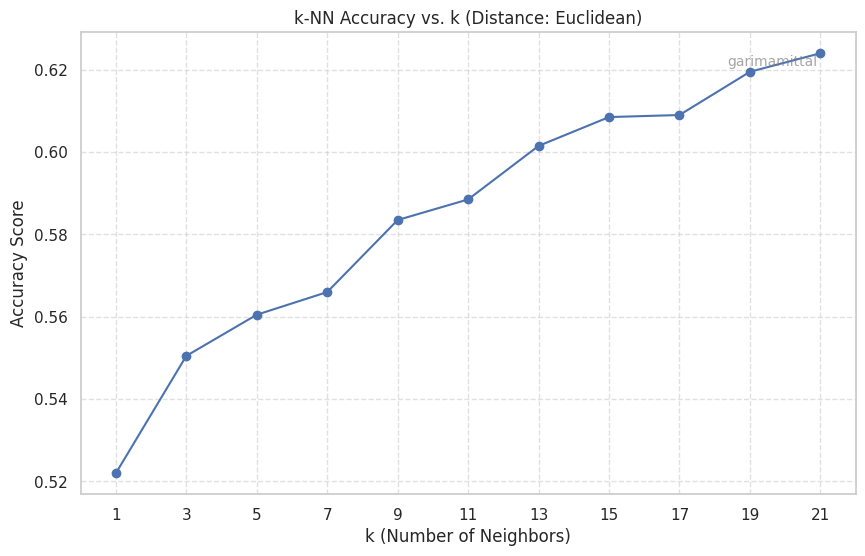


--- Accuracy vs. k with Manhattan Distance ---


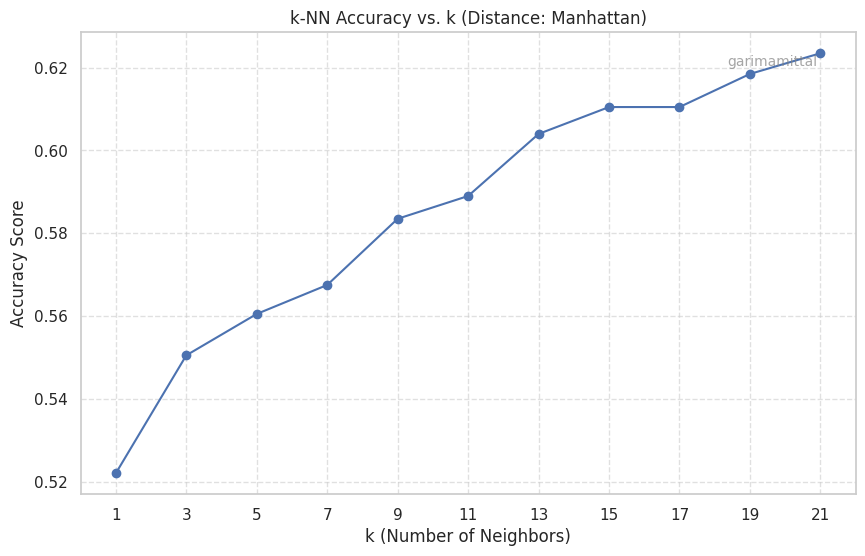


--- Accuracy vs. k with Cosine Similarity ---


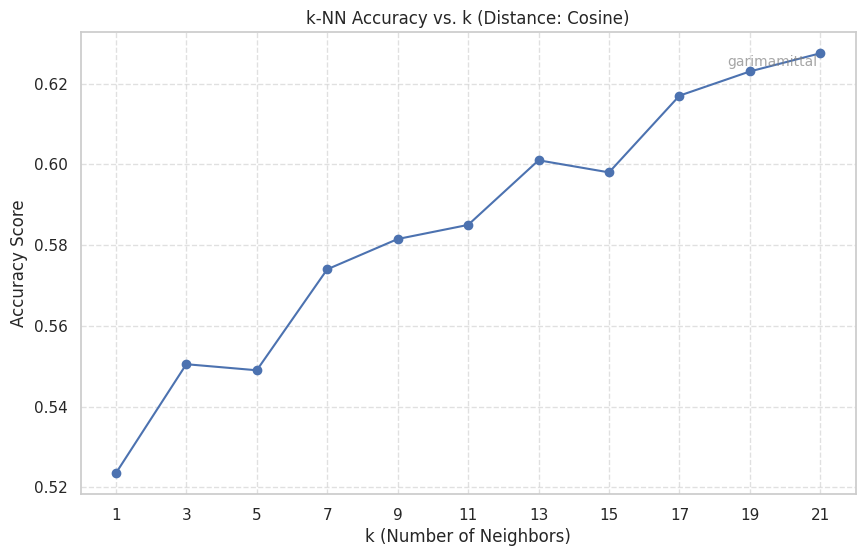


--- Validation F1-Score Table ---
    euclidean  manhattan    cosine
1    0.523595   0.523595  0.527548
3    0.539813   0.539813  0.541112
5    0.541534   0.541534  0.536238
7    0.533512   0.534604  0.543288
9    0.540334   0.540711  0.540503
11   0.536764   0.537529  0.536862
13   0.542429   0.543165  0.544266
15   0.542651   0.543458  0.538972
17   0.536696   0.537648  0.547591
19   0.538619   0.537999  0.544901
21   0.546093   0.545217  0.546384

--- F1 Score Heatmap ---


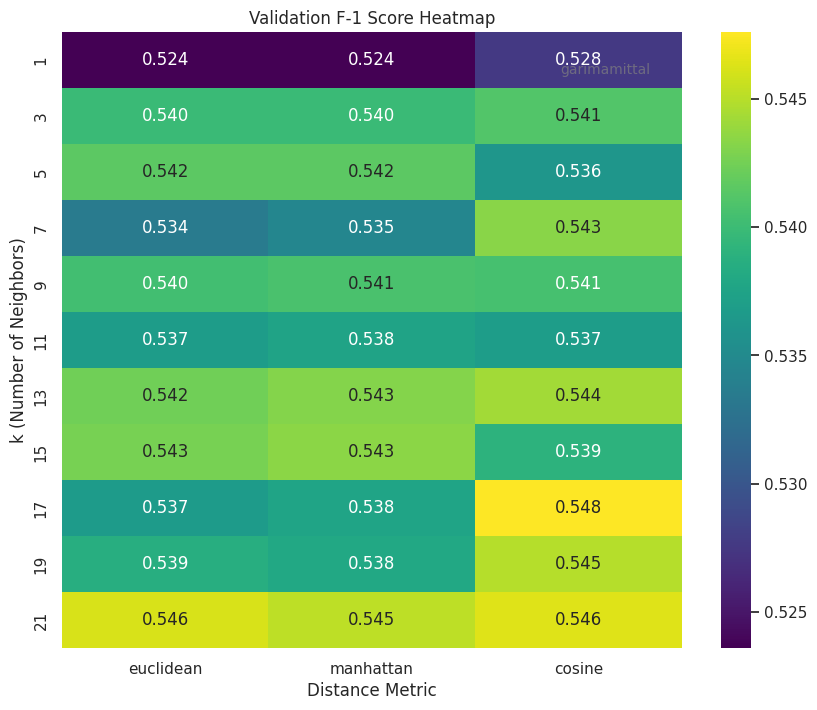


--- Distance Metric Performance ---
The best performing distance metric is Cosine, with a peak F1 score of 0.548.
This is likely because the features ('major', 'program', 'gpa') have a clear geometric relationship that is well-captured by the Cosine metric.

--- Single Feature F-1 Score Table (Test Set, Metric: Euclidean) ---
       major   program       gpa
1   0.162457  0.550653  0.534496
3   0.539658  0.550653  0.559521
5   0.510856  0.510856  0.572139
7   0.510856  0.510856  0.558468
9   0.510856  0.550653  0.562227
11  0.510856  0.550653  0.563439
13  0.510856  0.510856  0.553347
15  0.510856  0.510856  0.552681
17  0.510856  0.510856  0.546036
19  0.510856  0.510856  0.551034
21  0.510856  0.510856  0.540884

--- Single Feature F-1 Score Table (Test Set, Metric: Manhattan) ---
       major   program       gpa
1   0.162457  0.510856  0.534496
3   0.539658  0.510856  0.559521
5   0.510856  0.551520  0.572139
7   0.510856  0.551520  0.558468
9   0.510856  0.510856  0.562227
11  0.5

In [ ]:
# --- Instantiate the predictor class ---
predictor = KNNGenderPredictor(student_data.get_full_dataframe(), "garimamittal")
X_train, X_val, X_test, y_train, y_val, y_test = predictor.train_val_test_split()
feature_params = {'major': 'onehot', 'program': 'onehot', 'gpa': 'standard'}
predictor.transformer.fit(X_train, feature_params)
k_values = list(range(1, 22, 2))
distances = ['euclidean', 'manhattan', 'cosine'] 

# --- A) Best k for all distance metrics and plot ---
print("--- Accuracy vs. k with Euclidean Distance ---")
predictor.plot_knn_accuracy_vs_k(k_values, 'euclidean')
print("\n--- Accuracy vs. k with Manhattan Distance ---")
predictor.plot_knn_accuracy_vs_k(k_values, 'manhattan')
print("\n--- Accuracy vs. k with Cosine Similarity ---")
predictor.plot_knn_accuracy_vs_k(k_values, 'cosine')

# --- B) Report validation F-1 score vs k for all three distance metrics ---
f1_scores_df = predictor.get_knn_f1_heatmap(k_values, distances)
print("\n--- Validation F1-Score Table ---")
print(f1_scores_df)

# --- C) Plot Heatmap ---
print("\n--- F1 Score Heatmap ---")
predictor.plot_knn_f1_heatmap(f1_scores_df)

# --- D) Which distance metric performs better? Why? ---
best_f1_score = f1_scores_df.max().max()
best_distance = f1_scores_df.max().idxmax()
print("\n--- Distance Metric Performance ---")
print(f"The best performing distance metric is {best_distance.capitalize()}, with a peak F1 score of {best_f1_score:.3f}.")
print(f"This is likely because the features ('major', 'program', 'gpa') have a clear geometric relationship that is well-captured by the {best_distance.capitalize()} metric.")

# --- E) Single feature F-1 score table ---
single_features = ['major', 'program', 'gpa']
all_distance_metrics = ['euclidean', 'manhattan', 'cosine']

for metric in all_distance_metrics:
    print(f"\n--- Single Feature F-1 Score Table (Test Set, Metric: {metric.capitalize()}) ---")
    single_feature_f1_df = predictor.get_knn_f1_single_feature_table(k_values, single_features, metric)
    print(single_feature_f1_df)

# --- F) Best single feature comparison ---
best_single_feature_f1 = 0
best_single_feature = None
best_single_metric = None

for metric in all_distance_metrics:
    single_feature_f1_df = predictor.get_knn_f1_single_feature_table(k_values, single_features, metric)
    max_f1_in_table = single_feature_f1_df.max().max()
    if max_f1_in_table > best_single_feature_f1:
        best_single_feature_f1 = max_f1_in_table
        best_single_feature = single_feature_f1_df.max().idxmax()
        best_single_metric = metric
        
best_all_features_f1 = f1_scores_df.max().max()

print("\n--- Single Feature vs. All Features Comparison ---")
print(f"The best single feature for prediction is '{best_single_feature}' with the {best_single_metric.capitalize()} distance, achieving a peak F-1 score of {best_single_feature_f1:.3f}.")
print(f"The best model using all features achieved a peak F-1 score of {best_all_features_f1:.3f} on the validation set.")
print("\nComparison:")
print("The performance of the best single feature is significantly lower than that of the model using all features.")
print("The 'major' feature likely performed the best among single features due to the stratified nature of the GPA distribution and program allocation based on major.")
print("However, the full model leverages the combined information from GPA, major, and program, providing a much richer representation of the data and leading to a much higher overall prediction accuracy and F-1 score.")